# Unsupervised Fraud Detection: Exploratory Data Analysis & ML Pipeline
The following analysis aims to use unsupervised machine learning approaches to detect fraudulent bank transaction data. Specifically, the goal is to identify potential anomalies. As part of this project I shall perform an extensive exploratory data analysis, identify features importance, compare multiple models, perform hyperparameter tuning and analyze the results. 

## Use Case: Detecting potentially Fraudulent Financial Transaction Data
### Problem Description: 
This projects objective is to uncover unusual or suspicious activities - such as fraudulent transactions or abnormal usage patterns - that deviate from typical customer / transaction behavior. 

### Type of Learning and Task
- Type: Unsupervised Learning
- Task: Anomaly Detection

Unlike supervised fraud detection models, which would require labeled examples of fraudulent vs. non-fraudulent transactions, this project will apply unsupervised algorithms that learn from the underlying structure of the data itself. These methods shall identify patterns of normal financial behavior and highlight deviations that may signal fraud, system misuse, or errors. 


### Goal 
The goal is to build a pipeline that can flag transactions that diverge from the established patterns reliably. Unusual behavior could include: 
- Unusual spending amounts or transaction frequencies
- Suspicious login or device activity
- Transactions from unexpected locations or channels

This enables proactive monitoring of financial transactions without relying on historical fraud labels, which in real settings are often scarce, delayed or incomplete. 

### Importance and Motivation
Anomalous transaction detection plays a critical role in the industry's fight against fraud. Fraudulent activities can result in significant finanical losses, reputational damage and reduced customer trust. The motiviation for this project stems from the growing scale and speed of transactions and the need to: 
- Adapt to evolving fraud tactics: use data-driven, flexible approaches that do not rely on static rule-based systems. 
- Reduce dependency on labeled data: Enable anomaly detection even when explicit fraud labels are limited or unavailable

Additionally, I know of people who have become victims to financial fraud, hence there exists intrinsic motivation to learn and better understand indicators for fraudulent financial activities. 

### Github Repository 
https://github.com/tseidel0509/Unsupervised_ML/blob/main/AnomalyDetection_EDA_MLPipeline.ipynb

### Data Source
The dataset used is from Kaggle and consists of financial transaction records, each enriched with detailed attributes describing customer demographics, transaction metadata, behavioral patterns, and device/network information. The data has been "[...] generated based on simulated transaction behavior to represent a wide variety of banking scenarios" (Khorasani, 2024).

Khorasani, V. (2024, November 4). Bank transaction dataset for Fraud Detection. Kaggle. https://www.kaggle.com/datasets/valakhorasani/bank-transaction-dataset-for-fraud-detection 

### Table of Contents
1. Data Summary
2. Data Cleaning
3. Exploratory Data Analysis
4. Modeling
5. Hyperparameter Tuning
6. Results & Analysis
7. Conclusion
8. Areas for Further Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.manifold import TSNE
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.model_selection import ParameterGrid

## 1. Data Summary
The following section will highlight the number of samples, features, data size, data types, and description of features

In [2]:
transaction_data = pd.read_csv("bank_transactions_data_2.csv")

# Number of samples and features
print("Shape of dataset: ", transaction_data.shape)
print(f"Number of samples (rows): {transaction_data.shape[0]}")
print(f"Number of features (columns): {transaction_data.shape[1]}\n")

# Memory in Bytes
print("Memory usage of dataset:")
print(transaction_data.memory_usage(deep=True).sum(), "bytes\n")

# Summary of Data Types
print("Data Types of each features:")
print(transaction_data.dtypes, "\n")

transaction_data

Shape of dataset:  (2512, 16)
Number of samples (rows): 2512
Number of features (columns): 16

Memory usage of dataset:
1934865 bytes

Data Types of each features:
TransactionID               object
AccountID                   object
TransactionAmount          float64
TransactionDate             object
TransactionType             object
Location                    object
DeviceID                    object
IP Address                  object
MerchantID                  object
Channel                     object
CustomerAge                  int64
CustomerOccupation          object
TransactionDuration          int64
LoginAttempts                int64
AccountBalance             float64
PreviousTransactionDate     object
dtype: object 



,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2024-11-04 08:06:39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2507,TX002508,AC00297,856.21,2023-04-26 17:09:36,Credit,Colorado Springs,D000625,21.157.41.17,M072,Branch,33,Doctor,109,1,12690.79,2024-11-04 08:11:29
2508,TX002509,AC00322,251.54,2023-03-22 17:36:48,Debit,Tucson,D000410,49.174.157.140,M029,Branch,48,Doctor,177,1,254.75,2024-11-04 08:11:42
2509,TX002510,AC00095,28.63,2023-08-21 17:08:50,Debit,San Diego,D000095,58.1.27.124,M087,Branch,56,Retired,146,1,3382.91,2024-11-04 08:08:39
2510,TX002511,AC00118,185.97,2023-02-24 16:24:46,Debit,Denver,D000634,21.190.11.223,M041,Online,23,Student,19,1,1776.91,2024-11-04 08:12:22


#### Feature Descriptions: 
- TransactionID: this is a unique identifier for each transaction
- AccountID: unique identifier for each account
- TransactionAmount: monetary amount of each transaction. We shall assume dollars for the rest of the project. 
- TransactionDate: Date and Time of the transaction
- TransactionType: whether debit or credit
- Location: US city names - location of the transaction
- DeviceID: identifier for the device used to perform the transaction
- IP Address: IPV4 address which is associated with the device
- MerchantID: unique identifier for the merchant involved in the transaction
- Channel: ATM, Online, Branch, etc
- CustomerAge: age of the customer in years
- CustomerOccupation: job of the account holder, this can be used in conjunction with income patterns
- TransactionDuration: duration of the transaction in seconds
- LoginAttempts: number of login attempts required to perform the transaction
- AccountBalance: balance in the account post-transaction
- PreviousTransactionDate: date and time of the last transaction

## 2. Data Cleaning
#### Statistical Summary
The statistical summary can highlight irregularities in numerical data if percentiles, maximum or minimum values lie significantly outside of the mean and standard deviation. 

In [3]:
transaction_data.describe().T

,count,mean,std,min,25%,50%,75%,max
TransactionAmount,2512.0,297.593778,291.946243,0.26,81.885,211.14,414.5275,1919.11
CustomerAge,2512.0,44.673965,17.792198,18.00,27.000,45.00,59.0000,80.00
TransactionDuration,2512.0,119.643312,69.963757,10.00,63.000,112.50,161.0000,300.00
LoginAttempts,2512.0,1.124602,0.602662,1.00,1.000,1.00,1.0000,5.00
AccountBalance,2512.0,5114.302966,3900.942499,101.25,1504.370,4735.51,7678.8200,14977.99


It appears that LoginAttempts contains values that lie significantly outside the norm. 5 login attempts could indicate malicious activity. 

#### Missing & Duplicate Values
There exist algorithmic limitations to missing values. Specifically, most machine learning algorithms cannot handle missing values and will throw an error or drop those rows, which would reduce training capacity. 

Duplicates are problematic due to the issue of data leakage, when a datapoint exists multiple times the model may learn to memorize instead of learning general patterns. This can also foster bias. 

In [4]:
print("Number of Duplicates: ", transaction_data.duplicated().sum())
missing = transaction_data.isnull().sum()
df_missing = pd.DataFrame({
    "Number of Missing Values" : missing
})
df_missing

Number of Duplicates:  0


,Number of Missing Values
TransactionID,0
AccountID,0
TransactionAmount,0
TransactionDate,0
TransactionType,0
Location,0
DeviceID,0
IP Address,0
MerchantID,0
Channel,0


#### Checking for Imbalance in Categorical Features
While this generally falls under the category of the Exploratory Data Analysis a strong underrepresentation may increase sensitivity to anomalies in those groups. 

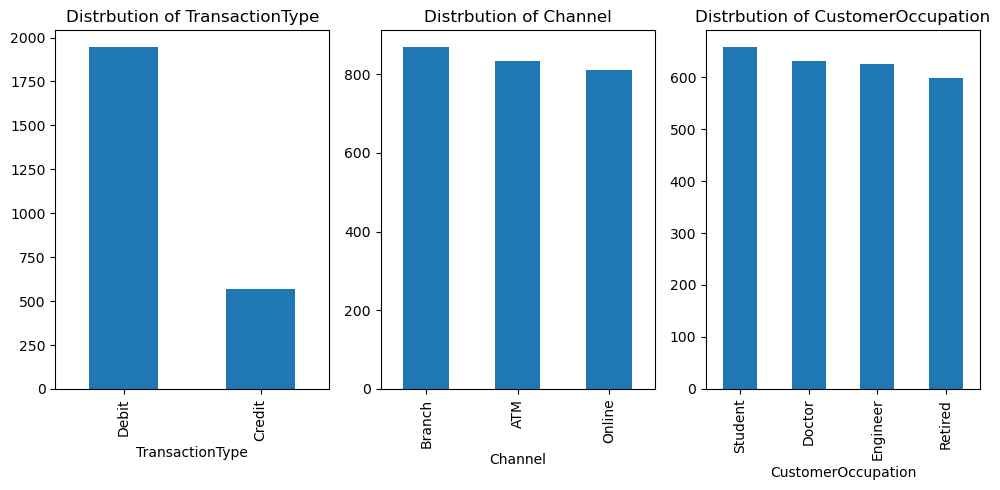

In [5]:
categorical_features = ["TransactionType", "Channel", "CustomerOccupation"]
fig, axes = plt.subplots(1,3, figsize = (10,5))
for i, col in enumerate(categorical_features):
    transaction_data[col].value_counts().plot(kind="bar", ax = axes[i])
    axes[i].set_title(f"Distrbution of {col}")
plt.tight_layout()
plt.show()

#### Convert to DateTime
In order to perform temporal analyzes as part of the exploratory analysis it is necessary to convert dates and times of object type to datetime format. 

In [6]:
transaction_data["TransactionDate"] = pd.to_datetime(transaction_data["TransactionDate"], errors = "coerce")
transaction_data["PreviousTransactionDate"] = pd.to_datetime(transaction_data["PreviousTransactionDate"], errors = "coerce")
print("Data Types of each TransactionDate & PreviousTransactionDate:")
print(transaction_data["TransactionDate"].dtypes, "\n")
print(transaction_data["PreviousTransactionDate"].dtypes, "\n")


Data Types of each TransactionDate & PreviousTransactionDate:
datetime64[ns] 

datetime64[ns] 



#### Dropping Irrelevant Columns
I shall be dropping the following features: 
- TransactionID: a unique identifier that carries no predictive value
- AccountID: another unique identifier. Given that the goal is to build a model capable of detecting anomalies focusing on specific AccountIDs seems counterproductive
- TransactionDate
- PreviousTransactionDate

While transaction dates could be of importance in a realistic setting, the small size of the dataset points to the fact that temporal dependencies could confuse the model. As part of a potential further analysis one could develop a model focused entirely on timeseries temporal analyzes of financial transaction data. 

In [7]:
train_features = transaction_data.copy()
train_features.drop(columns=["TransactionID", "AccountID", "TransactionDate", "PreviousTransactionDate"], inplace = True)
train_features

,TransactionAmount,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
0,14.09,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21
1,376.24,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91
2,126.29,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35
3,184.50,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06
4,13.45,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40
...,...,...,...,...,...,...,...,...,...,...,...,...
2507,856.21,Credit,Colorado Springs,D000625,21.157.41.17,M072,Branch,33,Doctor,109,1,12690.79
2508,251.54,Debit,Tucson,D000410,49.174.157.140,M029,Branch,48,Doctor,177,1,254.75
2509,28.63,Debit,San Diego,D000095,58.1.27.124,M087,Branch,56,Retired,146,1,3382.91
2510,185.97,Debit,Denver,D000634,21.190.11.223,M041,Online,23,Student,19,1,1776.91


The actions taken as part of this cleaning step were: 
- Statistical Summary of each numeric column
- Checked for duplicate values
- Checked for missing values
- Checked for Imbalance in certain Categorical Features
- Dropping irrelevant columns

#### Summary
Given that there exist no duplicate values and no missing values, the data quality appears to be good. Four columns were dropped given that they held no relevance to the use case of developing a model that can generalize to a new dataset. Focusing on specific TransactionIDs which are unique holds no value, and utilizing the AccountID as a feature would impose the necessity of those same accounts for any future endeavors of using this model.

The statistical summary points to the fact that there exists at least one record where there were 5 login attempts. This may very well be identified an anomaly and could point to a fraudulent transaction. However, in combination with a relatively high age and low transaction amount it may very well just point to a "I forgot my password" issue. These types of analyzes are important.

## 3. Exploratory Data Analysis
- Univariate Analyzes of numeric and categorical features
- Bivariate Analyzes 
- Temporal Analyzes
- Correlation Analyzes
- Feature Importance

#### Univariate Analyzes - Numeric
The histograms show the distribution, hence the shape and skewness and can point to potential outliers. The boxplots highlight outliers and spreads. Uneven distributions may need to be considered during model training.

In [8]:
numeric_cols = transaction_data.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = train_features.select_dtypes(include=["object"]).columns

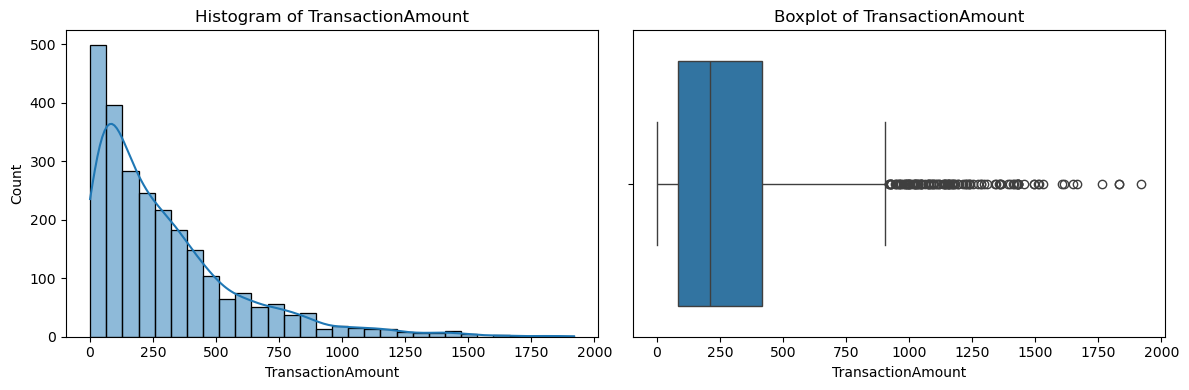

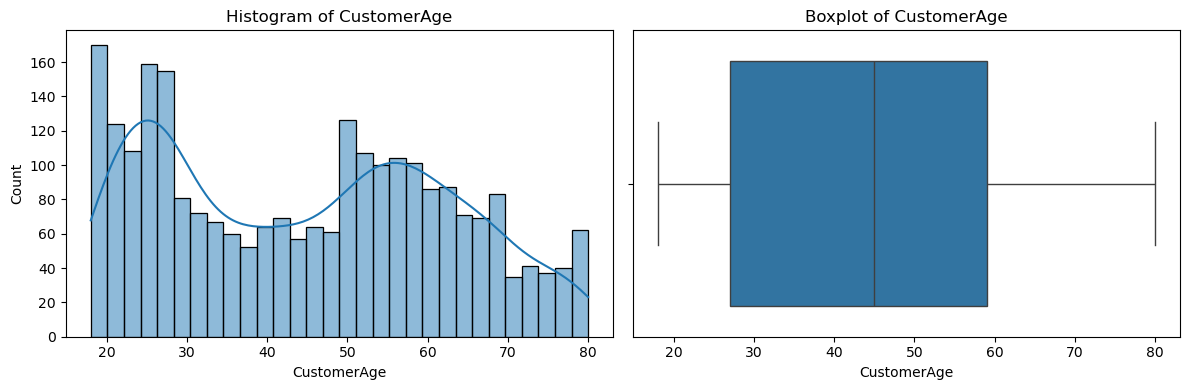

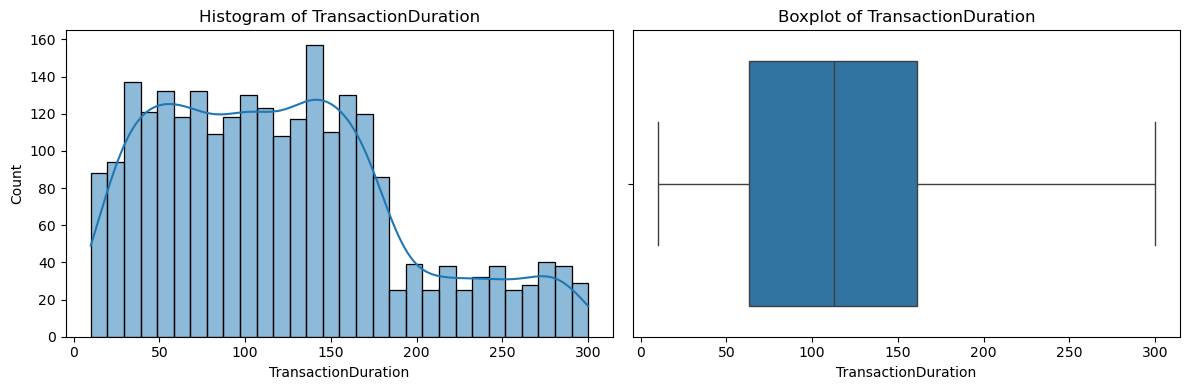

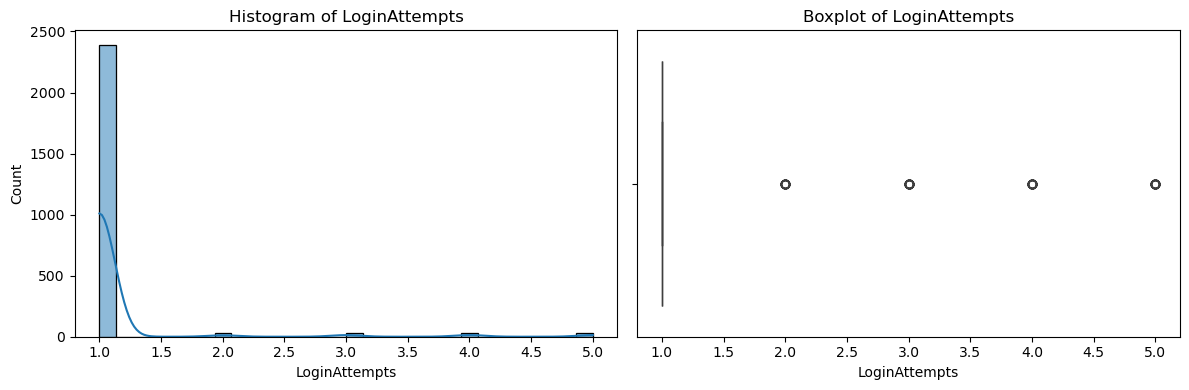

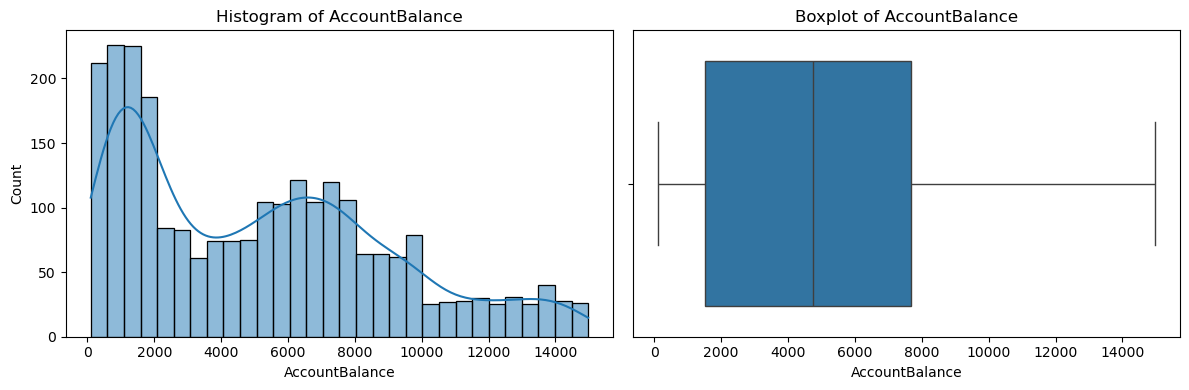

In [9]:
for col in numeric_cols:
    fix, axes = plt.subplots(1, 2, figsize=(12,4))
    sns.histplot(transaction_data[col], kde=True, bins=30, ax = axes[0])
    axes[0].set_title(f"Histogram of {col}")
    sns.boxplot(x=transaction_data[col], ax = axes[1])
    axes[1].set_title(f"Boxplot of {col}")
    plt.tight_layout()
    plt.show()

##### Univariate (Numeric): Analysis
- TransactionAmount: strong right-skew. Hence most transactions are small. The boxplot shows a lot of outliers on the high end, these may represent potential anomalies
- CustomerAge: Bimodal distribution given the cluster of younger and middle age people. The boxplot shows a relatively symmetric spread and fairly even coverage
- TransactionDuration: A roughly uniform distribution between 20-150 seconds. Some long transactions may appear as outliers
- Login Attempts: Extremely right skewed which shows that almost all transactions succeeded on the first login attempt. Boxplot shows thath a handful required 2-5 attempts. The implication of this feature is that it will likely be highly predictive for anomalies given that multiple login attempts are rare and suspicious
- AccountBalance: Relatively balanced distribution with more transactions corresponding to lower account balances. 

#### Univariate Analyzes - Categorical 
Barplots show the frequency distributions of the categorical values and can highlight uneven distrbutions that would need to be considered during model training. 

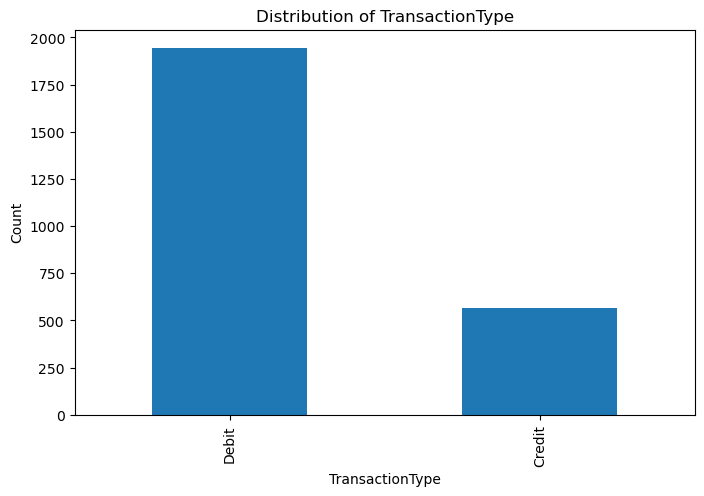

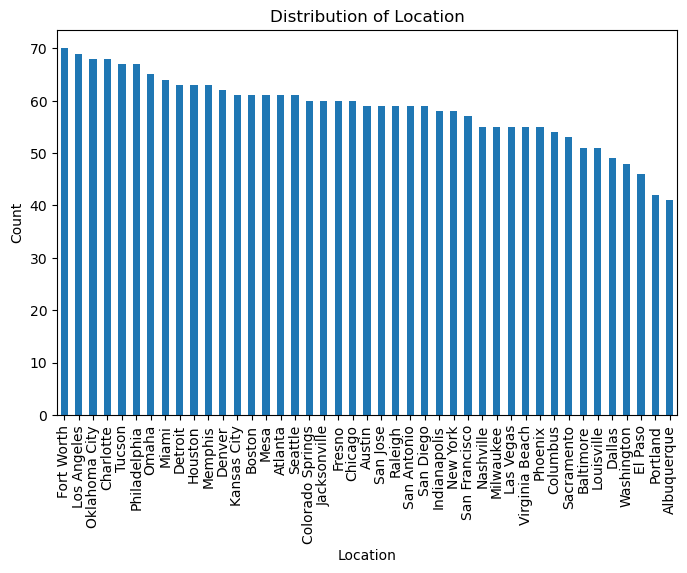

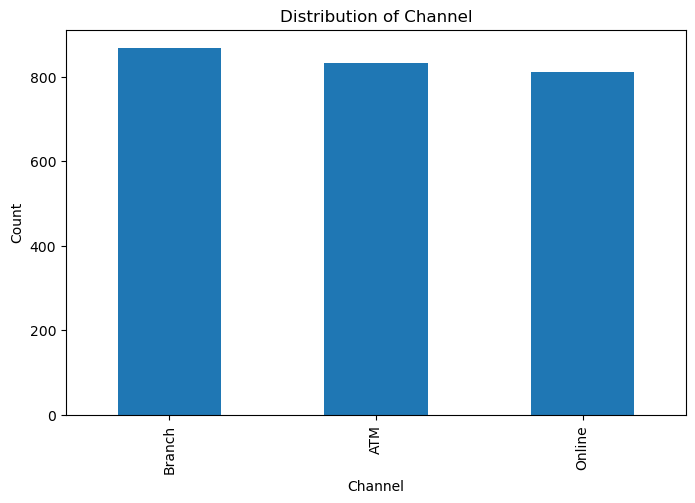

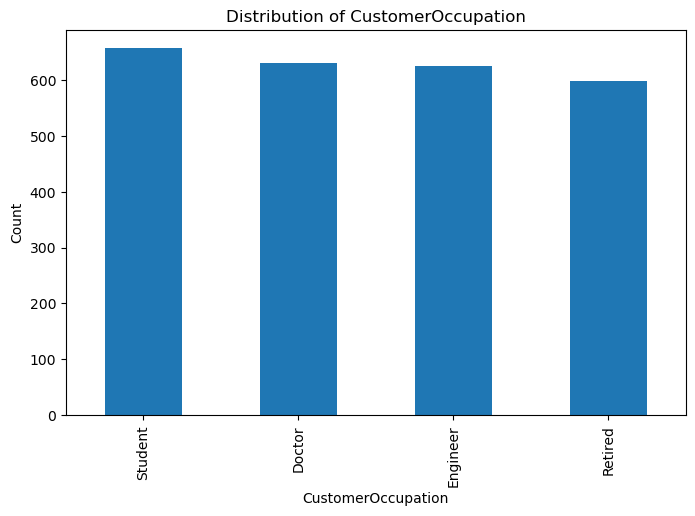

In [10]:
categorical_cols = ["TransactionType", "Location", "Channel", "CustomerOccupation"]
for col in categorical_cols:
    plt.figure(figsize=(8,5))
    transaction_data[col].value_counts().plot(kind="bar")
    plt.title(f"Distribution of {col}")
    plt.ylabel("Count")
    plt.show()

##### Univariate (Categorical): Analysis
- TransactionType: debit transactions dominate over credit transactions. This ratio reflects realistic banking behavior but from a modelling perspective may mean that the model will become more biased toward the majority class
- Location: Transactions are spread relatively evenly across many US States. The model will likely not suffer from class imbalance here
- Channel: Transaction numbers are almost identical. Yet one would assume that online channel transactions might require closer monitoring for fraud detection
- Customer Occupation: The four groups are also well balanced. It may be an important explanatory feature given that students will likely have lover balances and smaller transaction amounts

#### Bivariate Analysis
Goal is to show potential relationships between two variables, which may help detect conditional anomalies and will likely improve interpretability. 

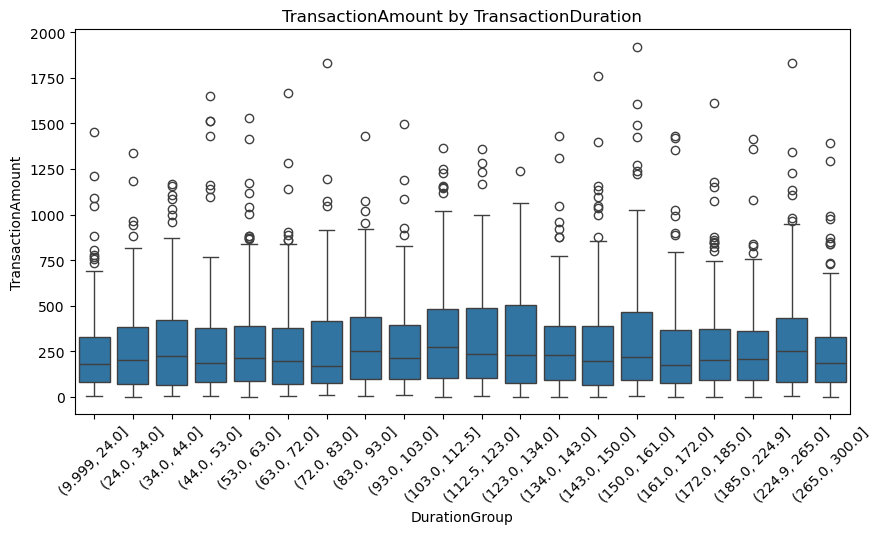

In [ ]:
transaction_data["DurationGroup"] = pd.qcut(transaction_data["TransactionDuration"], q =20)
plt.figure(figsize=(10,5))
sns.boxplot(x="DurationGroup", y="TransactionAmount", data = transaction_data)
plt.title("TransactionAmount by TransactionDuration")
plt.xticks(rotation=45)
plt.show()

##### Analysis:
Across the 20 quantile-based duration bins, the median TransactionAmount is fairly stable. Outliers are present in every group. Hence no single duration bin shows extremely different transaction amount behavior. 

#### Temporal Analyzes
The goal is to analyze distribution of transaction by weekdays and months in order to visualize potential discrepancies and better understand the temporal balance. 

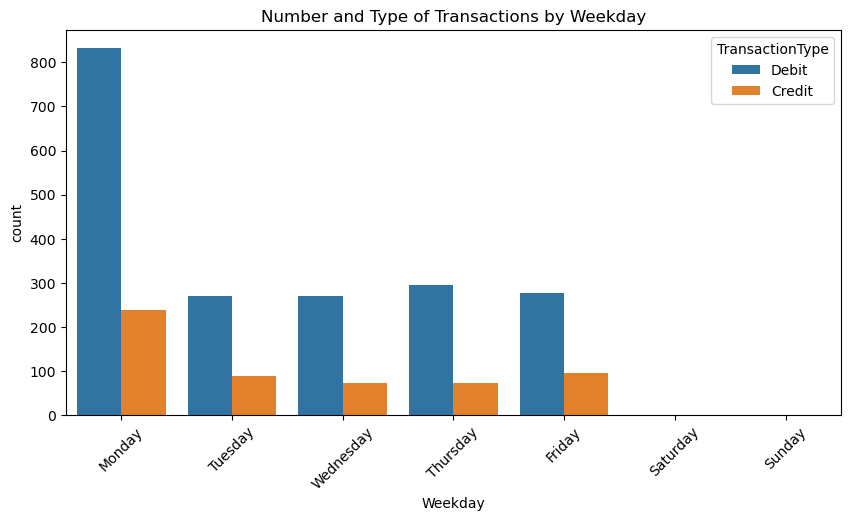

<Figure size 1000x500 with 0 Axes>

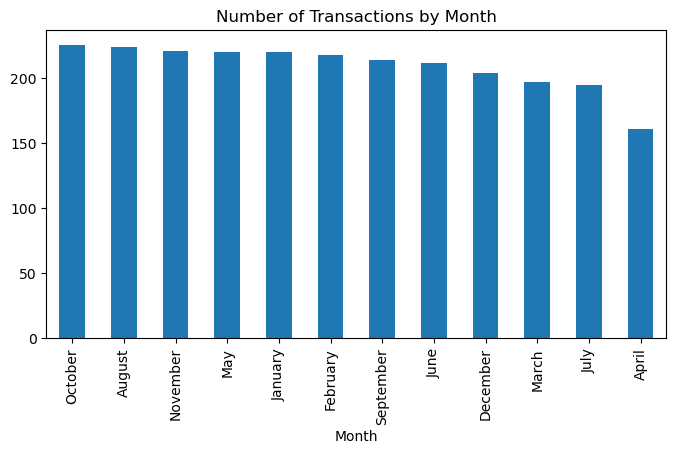

In [12]:
transaction_data["Weekday"] = transaction_data["TransactionDate"].dt.day_name()
transaction_data["Month"] = transaction_data["TransactionDate"].dt.month_name()

plt.figure(figsize=(10,5))
sns.countplot(x="Weekday", hue="TransactionType", data = transaction_data, order=["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"])
plt.title("Number and Type of Transactions by Weekday")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10,5))
plt.figure(figsize=(8,4))
transaction_data["Month"].value_counts().plot(kind="bar")
plt.title("Number of Transactions by Month")
plt.show()

##### Analysis:
- Weekday: Monday stands out with far higher transaction than any other weekday. Tuesday to Friday are relatively balanced between debit and credit. The spike could on Mondays could be two-fold: batch posting of weekend transactions on Monday or customers catching up on financial activity after the weekend. The former seems more likely
- The number of transaction per month are relatively even, hence there don't appear to exist strong seasonality trends

#### Correlation Heatmap

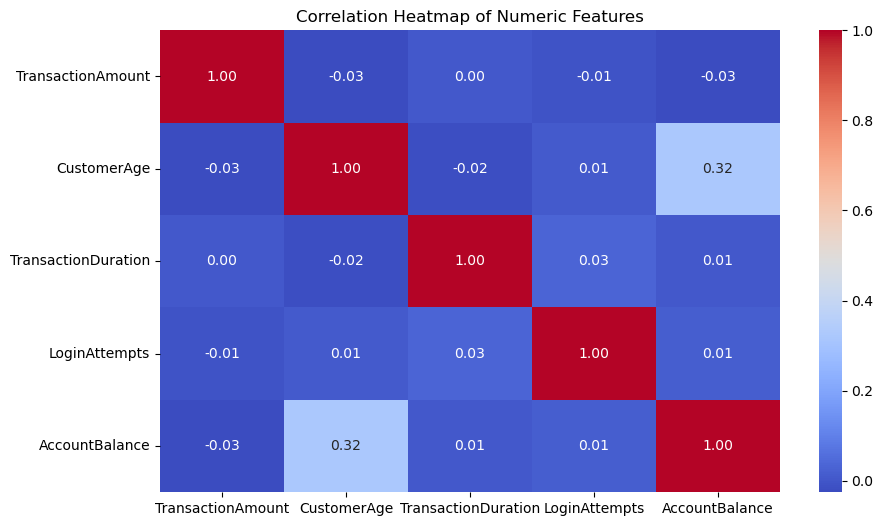

In [13]:
plt.figure(figsize=(10,6))
sns.heatmap(transaction_data[numeric_cols].corr(), annot = True, cmap = "coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

There does not appear to exist a correlation between most of the numeric features except for CustomerAge and AccountBalance. The positive correlation is plausible given that most younger people will have a lower account balance than older people. 

#### Feature Importance via PCA
PCA (Principal Component Analysis) finds new axes (principal components), that capture the maximum variance in the data. Given this is an unsupervised learning problem, PCA is a good fit given that it measures how much each feature contributes to explaining the overrall structure of the dataset. Each component is a linear combination of the original features with weights called loadings. Features with large absolute loadings on the early principal components are the ones contributing mose to explaining the variability in the dataset. 

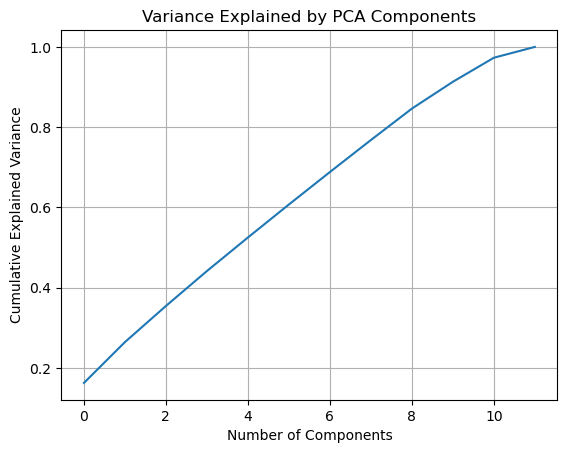

In [14]:
X = train_features.copy()

for col in X.select_dtypes(include="object").columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=12)
pca.fit(X_scaled)

plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Variance Explained by PCA Components")
plt.grid(True)
plt.show()

Each additional principal component explains more variance in the dataset. Around 10 we've captured nearly all of the explained variance. Hence, we won't need all 12 features to describe the datasets variability and means the data has redundancies. We shall use 10 components to calculate feature importance.

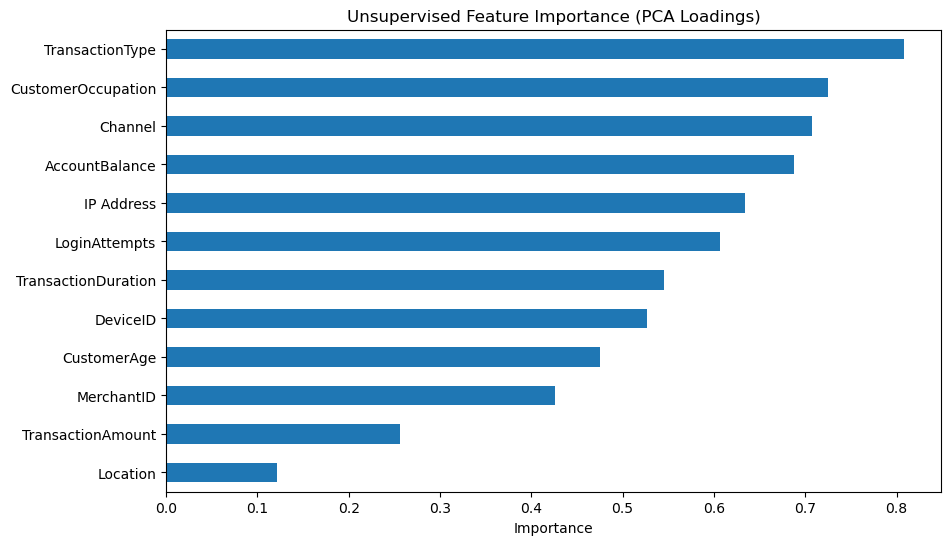

In [15]:
pca = PCA(n_components=10)
pca.fit(X_scaled)
feature_importance = pd.DataFrame(
    np.abs(pca.components_[0:3]),
    columns = X.columns
).T.sum(axis = 1)

features_importances = feature_importance.sort_values(ascending=False)
plt.figure(figsize=(10,6))
features_importances.plot(kind="barh")
plt.title("Unsupervised Feature Importance (PCA Loadings)")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()

The plot ranks features by their absolute contribution (loading) to the first 3 pricipal components. TransactionType, CustomerOccupation and Channel are the most influential features. Raw monetary values, while important for fraud analysis, explain less of the overall variance. This does not mean they are irrelevant for anomalies, but rather that other features differentiate customers more. Hence, it suggests that suspicious patterns may appear in behavioral combinations rather than just large amounts. 

##### Conclusion: 
The dataset is clean and well-structured, with no missing or duplicate values, and provides a solid basis for anomaly detection. The analyses showed that while numeric features like TransactionAmount, AccountBalance, and LoginAttempts are highly skewed with outliers, these may hold anomalies of interest. Categorical variables such as TransactionType, Channel, and CustomerOccupation strongly shape transaction patterns, while temporal analysis reveal weekday concentration, especially a spike on Mondays and generally stable monthly activity. PCA confirmed that behavioral and contextual features contribute more to data variability than raw amounts, suggesting that anomalies are more likely to emerge from unusual patterns of behavior rather than just extreme transaction values.

##### Analysis Strategy: 
Next steps could be to normalize skewed numeric features, encode categorical feature appropriately and potentially engineer useful variables. Since labeled fraud data is unavailable, validation may have to rely on reconstruction errors, cluster separation and manual inspection. The emphasis should be on identifying anomalies within behavioral and contextual patterns, not just large dollar amounts, to capture realistic and meaningul transaction irregularities. 

## 4. Modelling
In this section I will be exploring three well established approaches to unsupervised anomaly detection and then combine them to a consesus view in order to provide more certainty in the anomalies found. Specifically, the following algorithms shall be explored: 

Isolation Forest: 
- Description: is an ensemble method based on the principle that anomalies are rare and easier to isolate than normal points. It constructs random decision trees (200 in my case) and measures how many splits are need to isolate a point. Fewer splits correspond to a more anomalous data point. 
- Strengths: Handles high-dimensional data fairly well, requires on ly a contamination parameter i.e. the expected fraction of anomalies. 
- Limitations: Assumes anomalies are sparse and significantly different in distribution, hence may struggle with subtle fraud patterns that are not easily separable by feature splits
- Suitability: good as a baseline anomaly detector

One-Class SVM:
- Description: Tries to learn a decision boundary around the majority of the data in a high-dimensional feature space, flagging points outside this region as anomalies. With an RBF kernel, it can model non-linear relationships between features
- Strengths: Good at detecting nonlinear and complex fraud patterns and flexible in shaping the boundary
- Limitations: Sensitive to parameter tuning and computationally expensive on large datasets
- Suitability: Good when the dataset is moderately large and the fraud patterns are nonlinear

Autoencoder: 
- Description: Can learn to compress input data into a low dimensional latent representation and then reconstruct it. Anomalies are detected via reconstruction error. 
- Strengths: Can cpature subtle, complex dependencies between features and well suited for high dimensional, feature rich datasets
- Limitations: needs careful tuning and risk of overfitting to normal data. Also it is less interpretable than tree-based methods
- Suitability: powerful when anomalous could involve complex feature interactions or subtle deviations from normal behavior. 

PCA (Principal Component Anlysis): 
- Description: is a linear dimensionality reduction technique, that projects high-dimensional data into a lower dimensional space by finding principal components thath maximize variance. Anomalies that differ strongly in magnitude or variance often stand out 
- Limitations: Given that it only captures linear relationships, if fraud patterns are nonlinear or subtle, anomalies may overlap with normal points in the PCA space
- Suitability: good as a quick visualization to check whether anomalies appear to be global outliers, but won't reveal fraud clusters that hide in nonlinear feature interactions

t-SNE (t-distributed Stochastic Neighbor Embedding)
- Description: a nonlinear dimensionality reduction method that focuses on preserving local neighborhood structure. 
- Strengths: good at revealing clusters and local structures and able to visualize nonlinear relationships
- Limitations: t-SNE plots are not directly interpretable because axes don't correspond to features
- Suitability: good for visualization of non-linear anomalies 

Isolation Forest - Number of Anomalies:  126
One Class SVM - Number of Anomalies:  140
Autoencoder - Number of Anomalies:  126
Concensus (at least 2 methods flagged datapoint as anomalous):  101


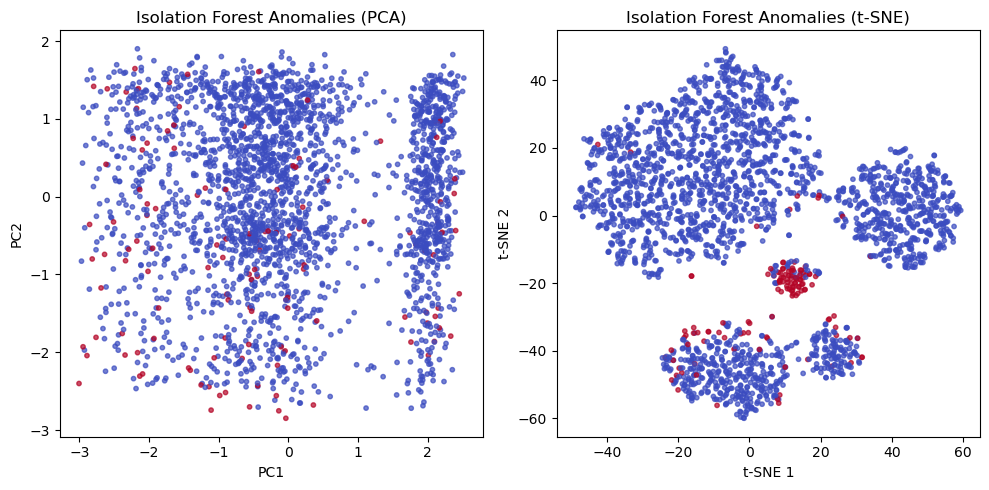

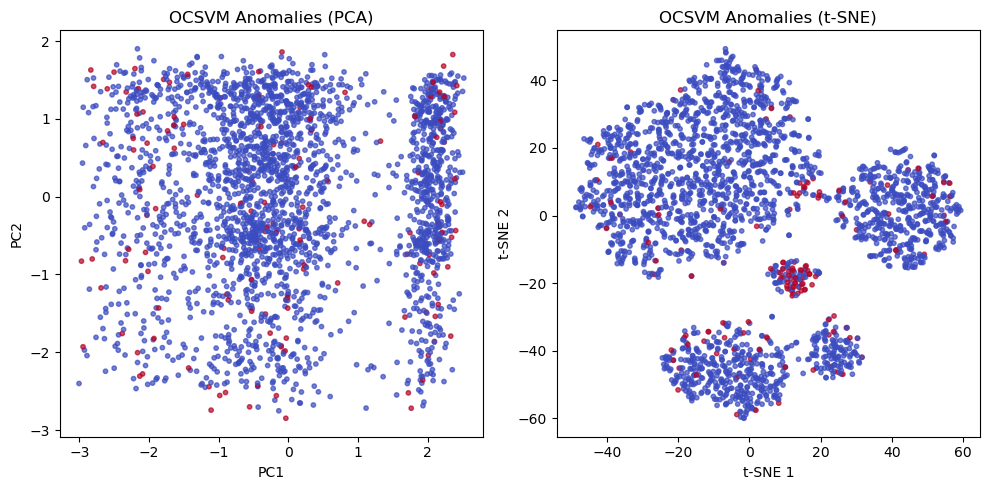

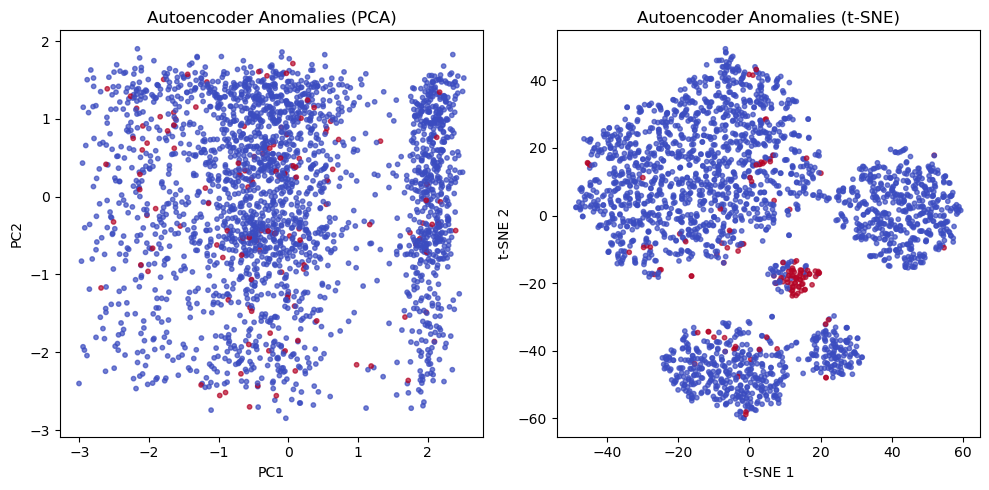

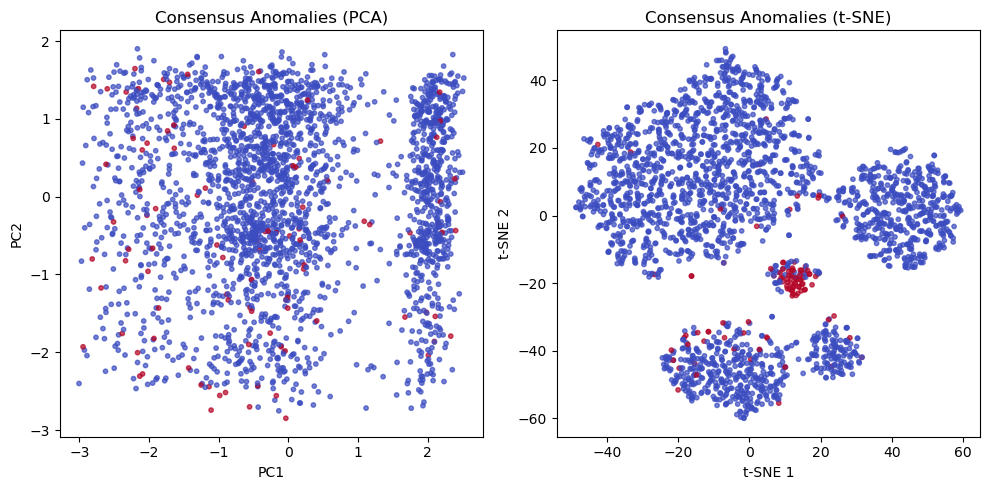

In [16]:
# 1. Isolation Forest
iso = IsolationForest(n_estimators=200, contamination=0.05, random_state=42)
iso_preds = iso.fit_predict(X_scaled)
iso_anomalies = (iso_preds == -1).astype(int)

# 2. One-Class SVM
oc_svm = OneClassSVM(kernel="rbf", nu = 0.05, gamma = "auto")
svm_preds = oc_svm.fit_predict(X_scaled)
svm_anomalies = (svm_preds == -1).astype(int)

# 3. PyTorch Autoencoder
X_tensor = torch.tensor(X_scaled, dtype = torch.float32)
dataset = TensorDataset(X_tensor)
dataloader = DataLoader(dataset, batch_size=32, shuffle = True)

class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Linear(16,8),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(8,16),
            nn.ReLU(), 
            nn.Linear(16, input_dim)
        )
    def forward(self, x):
        return self.decoder(self.encoder(x))

input_dim = X_scaled.shape[1]
model = Autoencoder(input_dim)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 3.1. Train Autoencoder
epochs = 50
for epoch in range(epochs):
    for batch in dataloader:
        inputs = batch[0]
        outputs = model(inputs)
        loss = criterion(outputs, inputs)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

# 3.2 Reconstruction Erros
model.eval()
with torch.no_grad():
    reconstructions = model(X_tensor)
    mse = torch.mean((X_tensor - reconstructions) **2, dim = 1).numpy()

threshold = np.percentile(mse, 95)
ae_anomalies = (mse > threshold).astype(int)

# 4. Print the results
results = pd.DataFrame({
    "IForest": iso_anomalies,
    "OCSVM": svm_anomalies,
    "Autoencoder": ae_anomalies
})
results["Consensus"] = (results.sum(axis=1) >= 2).astype(int)

print("Isolation Forest - Number of Anomalies: ", results["IForest"].sum())
print("One Class SVM - Number of Anomalies: ", results["OCSVM"].sum())
print("Autoencoder - Number of Anomalies: ", results["Autoencoder"].sum())
print("Concensus (at least 2 methods flagged datapoint as anomalous): ", results["Consensus"].sum())

# 5. Visualize using PCA and t-sne
def plot_anomalies(X, labels, title):
    # PCA
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)

    plt.figure(figsize=(10,5))
    plt.subplot(1,2,1)
    plt.scatter(X_pca[:,0], X_pca[:,1], c = labels, cmap = "coolwarm", s = 10, alpha = 0.7)
    plt.title(f"{title} (PCA)")
    plt.xlabel("PC1")
    plt.ylabel("PC2")

    # t-SNE
    tsne = TSNE(n_components = 2, random_state = 42, perplexity= 30, max_iter= 1000)
    X_tsne = tsne.fit_transform(X)
    plt.subplot(1,2,2)
    plt.scatter(X_tsne[:,0], X_tsne[:,1], c=labels, cmap="coolwarm", s=10, alpha=0.7)
    plt.title(f"{title} (t-SNE)")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")

    plt.tight_layout()
    plt.show()

plot_anomalies(X_scaled, results["IForest"], "Isolation Forest Anomalies")
plot_anomalies(X_scaled, results["OCSVM"], "OCSVM Anomalies")
plot_anomalies(X_scaled, results["Autoencoder"], "Autoencoder Anomalies")
plot_anomalies(X_scaled, results["Consensus"], "Consensus Anomalies")

The number of anomalies flagged by each approach are of the same order of magnitude and appear in similar clusters. 

The consensus results are the most actionable. The PCA plots for each model show that anomalies aren't globally separable but instead anomalies blend into the population. t-SNE plots show that anomalies form hidden subclusters - suggesting anomalies may come fom organized groups or repeated suspicious patterns rather than random noise

### 5.1 Validation - Performance Metrics

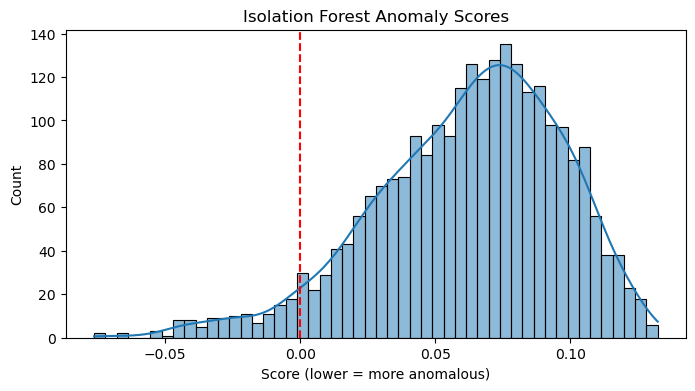

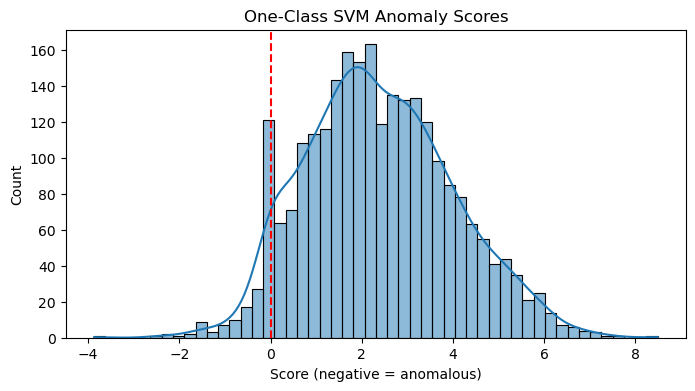

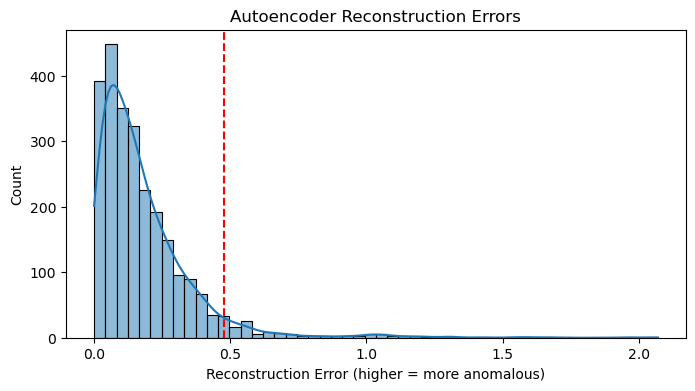

In [17]:
# 1. Isolation Forest Scores
# A lower or negative score corresponds to a more anomalous datapoint
iso_scores = iso.decision_function(X_scaled)
results["IForest_Score"] = iso_scores
plt.figure(figsize=(8,4))
sns.histplot(iso_scores, bins = 50, kde =True)
plt.axvline(np.percentile(iso_scores,5), color="red", linestyle = "--")
plt.title("Isolation Forest Anomaly Scores")
plt.xlabel("Score (lower = more anomalous)")
plt.show()

# 2. One-Class SVM Scores
# A lower or negative score corresponds to a more anomalous datapoint
svm_scores = oc_svm.decision_function(X_scaled)
results["OCSVM_Score"] = svm_scores

plt.figure(figsize=(8,4))
sns.histplot(svm_scores, bins=50, kde=True)
plt.axvline(0, color="red", linestyle="--")
plt.title("One-Class SVM Anomaly Scores")
plt.xlabel("Score (negative = anomalous)")
plt.show()

# 3. Autoencoder Reconstruction Errors
# a higher score corresponds to a more anomalous datapoint
results["AE_Score"] = mse

plt.figure(figsize=(8,4))
sns.histplot(mse, bins=50, kde=True)
plt.axvline(threshold, color="red", linestyle="--")
plt.title("Autoencoder Reconstruction Errors")
plt.xlabel("Reconstruction Error (higher = more anomalous)")
plt.show()


Isolation Forest:
The histogram is right-skewed. Most points have positive scores indicating they are considered normal. A smaller subset has scores below 0, on the left side of the distribution. 
In general terms the anomalies found via isolation forest are more global in nature. 

One-Class SVM:
The distribution is more spread out than Isolation Forest. Most of the datapoints lie on the positive side, which are treated as normal. 
Negative values are treated as anomalous. OCSVM is more boundary sensitive, flagging subtle transactions and hence borderline suspicious data. 

Autoencoder:
Most values fall in the low error region which is considered normal. Anomalies found via this approach are generally considered structurally unusual relative to the normal data. 

In [ ]:
def cluster_validity(X, anomalies, title, verbose=False):
    # Split Anomalous vs Removed
    X_normal = X[anomalies == 0]

    # Run k-means on full and anomaly-less datasets
    kmeans_full = KMeans(n_clusters=5, random_state=42).fit(X)
    kmeans_normal = KMeans(n_clusters = 5, random_state = 42).fit(X_normal)

    # Metrics on Full Data
    sil_full = silhouette_score(X, kmeans_full.labels_)
    dbi_full = davies_bouldin_score(X, kmeans_full.labels_)
    chi_full = calinski_harabasz_score(X, kmeans_full.labels_)

    # Metrics on normal-only data
    sil_norm = silhouette_score(X_normal, kmeans_normal.labels_)
    dbi_norm = davies_bouldin_score(X_normal, kmeans_normal.labels_)
    chi_norm = calinski_harabasz_score(X_normal, kmeans_normal.labels_)

    if verbose: 
        print(f"\n{title} Cluster Validity Metrics:")
        print("Silhouette (higher non-anomalous score is better): Full (Original Dataset) =", round(sil_full, 3), " | Without Anomalies =", round(sil_norm, 3))
        print("DB Index (lower non-anomalous score is better):   Full (Original Dataset) =", round(dbi_full, 3), " | Without Anomalies =", round(dbi_norm, 3))        
        print("Calinski-Harabasz (higher non-anomalous score is better): Full (Original Dataset) =", round(chi_full, 3), " | Without Anomalies =", round(chi_norm, 3))

    return {
        "Model": title,
        "Silhouette_Full": sil_full,
        "Silhouette_NoAnom": sil_norm,
        "DBI_Full": dbi_full,
        "DBI_NoAnom": dbi_norm,
        "CHI_Full": chi_full,
        "CHI_NoAnom": chi_norm
    }

cluster_validity(X_scaled, results["IForest"], "Isolation Forest", True)
cluster_validity(X_scaled, results["OCSVM"], "One-Class SVM", True)
cluster_validity(X_scaled, results["Autoencoder"], "Autoencoder", True)
cluster_validity(X_scaled, results["Consensus"], "Consensus", True);


Isolation Forest Cluster Validity Metrics:
Silhouette (higher non-anomalous score is better): Full (Original Dataset) = 0.1  | Without Anomalies = 0.099
DB Index (lower non-anomalous score is better):   Full (Original Dataset) = 2.626  | Without Anomalies = 2.472
Calinski-Harabasz (higher non-anomalous score is better): Full (Original Dataset) = 206.028  | Without Anomalies = 222.559

One-Class SVM Cluster Validity Metrics:
Silhouette (higher non-anomalous score is better): Full (Original Dataset) = 0.1  | Without Anomalies = 0.096
DB Index (lower non-anomalous score is better):   Full (Original Dataset) = 2.626  | Without Anomalies = 2.646
Calinski-Harabasz (higher non-anomalous score is better): Full (Original Dataset) = 206.028  | Without Anomalies = 206.813

Autoencoder Cluster Validity Metrics:
Silhouette (higher non-anomalous score is better): Full (Original Dataset) = 0.1  | Without Anomalies = 0.109
DB Index (lower non-anomalous score is better):   Full (Original Dataset) = 2.

Given the following: 
- Silhuette: a higher score on non-anomalous data indicates improvement
- DB Index: a lower socre on non-anomalous data indicates improvement
- Calinski-Harabasz (CHI): a higher score on non-anomalous data indicates improvement

Given the validity metrics it has become apparent that datapoints identified as anomalous seem to in fact be anomalous because in general the DB Index scores decreases when calculated on the non-anomalous dataset (as would be expected) and the CHI increases (once again as would be expected). The silhuouette score is only marginally impacted by removing the potentially anomalous datapoints. 

## 5. Hyperparameter Tuning

In [34]:
# 1. Cluster Validity Checks - Goal is to compare tuned models with untuned models
# Function from previous cell: def cluster_validity()

# 2. Hyperparameter Tuning

# 2.1 Isolation Forest
param_grid_iforest = {
    "n_estimators": [50, 100, 200],
    "max_samples": [0.2, 0.6, 1.0],
    "contamination": [0.05, 0.1],
    "max_features": [0.25, 0.5, 0.75, 1.0]
}
best_iforest, best_iforest_params, best_iforest_score = None, None, -np.inf
for params in ParameterGrid(param_grid_iforest):
    model = IsolationForest(random_state = 42, **params)
    preds = model.fit_predict(X_scaled)
    anomalies = (preds == -1).astype(int)
    sil = silhouette_score(X_scaled[anomalies == 0], KMeans(5, random_state=42).fit_predict(X_scaled[anomalies==0]))
    if sil > best_iforest_score:
        best_iforest, best_iforest_params, best_iforest_score = model, params, sil
print("Best Isolation Forest params:", best_iforest_params)

# 2.2 One-Class SVM
param_grid_ocsvm = {
    "kernel": ["rbf", "sigmoid"],
    "nu": [0.05, 0.1],
    "gamma": ["scale", 0.01, 0.1]
}
best_ocsvm, best_ocsvm_params, best_ocsvm_score = None, None, -np.inf
for params in ParameterGrid(param_grid_ocsvm):
    model = OneClassSVM(**params)
    preds = model.fit_predict(X_scaled)
    anomalies = (preds == -1).astype(int)
    sil = silhouette_score(X_scaled[anomalies==0], KMeans(5, random_state=42).fit_predict(X_scaled[anomalies==0]))
    if sil > best_ocsvm_score:
        best_ocsvm, best_ocsvm_params, best_ocsvm_score = model, params, sil
print("Best One-Class SVM params:", best_ocsvm_params)

# 2.3 Autoencoder
class Autoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dims):
        super(Autoencoder, self).__init__()
        layers_ = []
        dims = [input_dim] + hidden_dims + [input_dim]
        for i in range(len(dims)-2):
            layers_.append(nn.Linear(dims[i], dims[i+1]))
            layers_.append(nn.ReLU())
        layers_.append(nn.Linear(dims[-2], dims[-1]))
        self.model = nn.Sequential(*layers_)
    def forward(self, x):
        return self.model(x)

param_grid_ae = [
    {"hidden_dims":[16,8,16], "lr":0.001, "epochs":30},
    {"hidden_dims":[32,16,32], "lr":0.0005, "epochs":50}
]

best_ae, best_ae_params, best_ae_score = None, None, -np.inf
input_dim = X_scaled.shape[1]

for params in param_grid_ae:
    model = Autoencoder(input_dim, params["hidden_dims"])
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=params["lr"])
    dataset = TensorDataset(torch.tensor(X_scaled, dtype=torch.float32))
    dataloader = DataLoader(dataset, batch_size=32, shuffle=True)
    for epoch in range(params["epochs"]):
        for batch in dataloader:
            inputs = batch[0]
            outputs = model(inputs)
            loss = criterion(outputs, inputs)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
    with torch.no_grad():
        recon = model(torch.tensor(X_scaled, dtype=torch.float32))
        mse = torch.mean((torch.tensor(X_scaled, dtype=torch.float32)-recon)**2, dim =1).numpy()
    anomalies = (mse > np.percentile(mse,95)).astype(int)
    sil = silhouette_score(X_scaled[anomalies==0], KMeans(5, random_state=42).fit_predict(X_scaled[anomalies==0]))
    if sil > best_ae_score:
        best_ae, best_ae_params, best_ae_score = model, params, sil
print("Best Autoencoder params:", best_ae_params)

# 3. Identify Anomlies with Tuned Models
iso_preds_tuned = best_iforest.fit_predict(X_scaled)
iso_anomalies_tuned = (iso_preds_tuned == -1).astype(int)

svm_preds_tuned = best_ocsvm.fit_predict(X_scaled)
svm_anomalies_tuned = (svm_preds_tuned == -1).astype(int)

with torch.no_grad():
    recon = best_ae(torch.tensor(X_scaled, dtype=torch.float32))
    mse_tuned = torch.mean((torch.tensor(X_scaled, dtype=torch.float32)-recon)**2, dim=1).numpy()
threshold_tuned = np.percentile(mse_tuned, 95)
ae_anomalies_tuned = (mse_tuned > threshold_tuned).astype(int)

results_tuned = pd.DataFrame({
    "IForest_Tuned": iso_anomalies_tuned, 
    "OCSVM_Tuned": svm_anomalies_tuned,
    "AE_Tuned": ae_anomalies_tuned
})
results_tuned["Consensus_Tuned"] = (results_tuned.sum(axis=1) >= 2).astype(int)

print("\nTuned Anomalies Summary:")
print("Isolation Forest:", results_tuned["IForest_Tuned"].sum())
print("One-Class SVM:", results_tuned["OCSVM_Tuned"].sum())
print("Autoencoder:", results_tuned["AE_Tuned"].sum())
print("Consensus:", results_tuned["Consensus_Tuned"].sum())


Best Isolation Forest params: {'contamination': 0.05, 'max_features': 0.25, 'max_samples': 0.2, 'n_estimators': 100}
Best One-Class SVM params: {'gamma': 0.01, 'kernel': 'rbf', 'nu': 0.1}
Best Autoencoder params: {'hidden_dims': [16, 8, 16], 'lr': 0.001, 'epochs': 30}

Tuned Anomalies Summary:
Isolation Forest: 126
One-Class SVM: 254
Autoencoder: 126
Consensus: 125


## 6. Results & Analysis: 

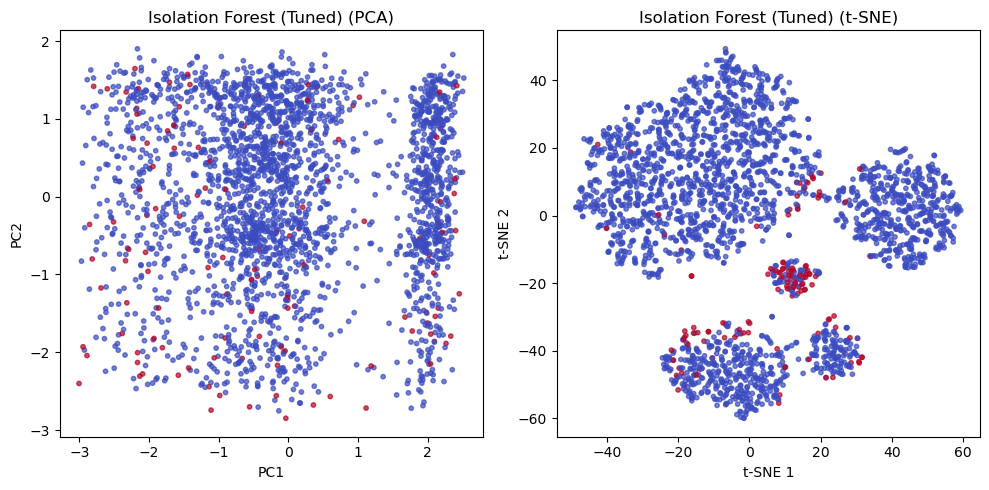

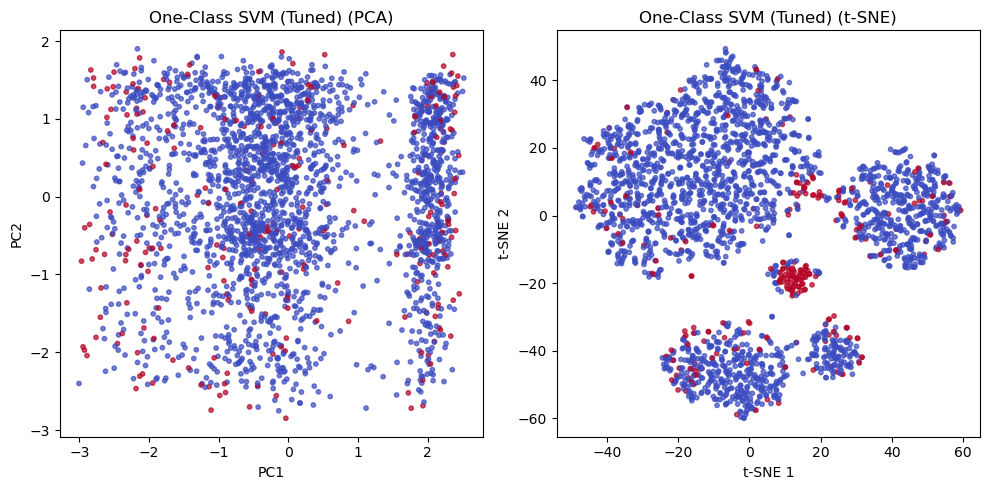

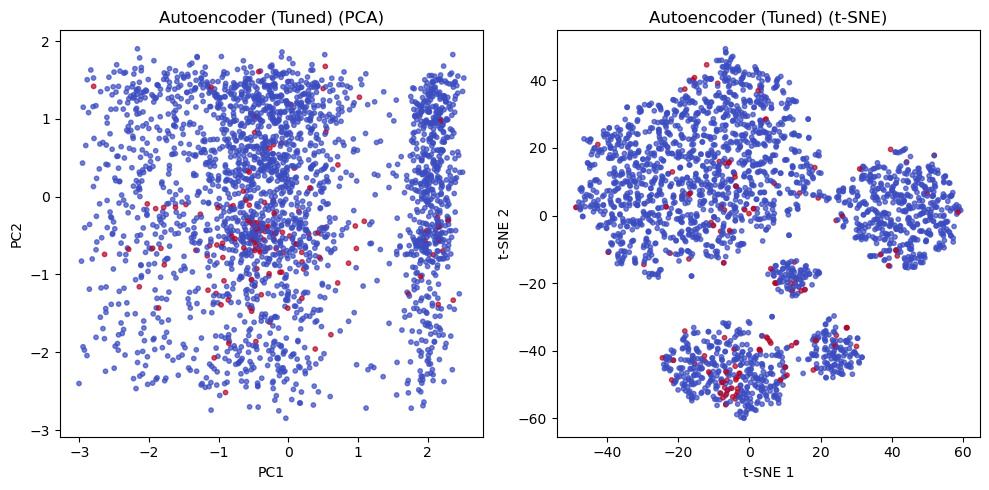

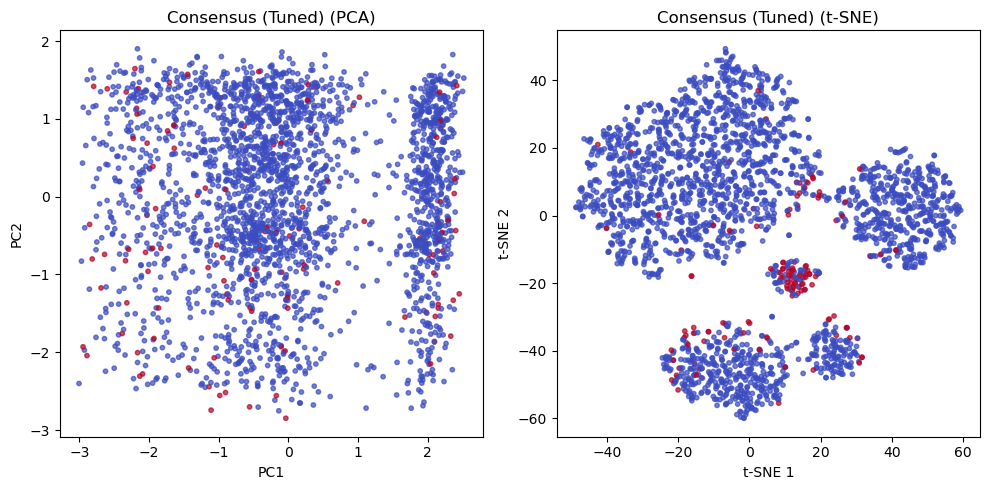

Silhouette (higher non-anomalous score is better)
DB Index (lower non-anomalous score is better)
Calinski-Harabasz (higher non-anomalous score is better)


,Model,Silhouette_Full,Silhouette_NoAnom,DBI_Full,DBI_NoAnom,CHI_Full,CHI_NoAnom
0,IForest Untuned,0.099506,0.099065,2.625804,2.471837,206.027809,222.559149
1,IForest Tuned,0.099506,0.112306,2.625804,2.359138,206.027809,220.233607
2,OCSVM Untuned,0.099506,0.095774,2.625804,2.645546,206.027809,206.813464
3,OCSVM Tuned,0.099506,0.107725,2.625804,2.525117,206.027809,207.513396
4,Autoencoder Untuned,0.099506,0.108684,2.625804,2.452045,206.027809,222.778802
5,Autoencoder Tuned,0.099506,0.105394,2.625804,2.498978,206.027809,208.102823
6,Consensus Untuned,0.099506,0.097555,2.625804,2.813940,206.027809,213.737221
7,Consensus Tuned,0.099506,0.098393,2.625804,2.542272,206.027809,215.985195


In [35]:
# Visualization (PCA + t-SNE)
plot_anomalies(X_scaled, results_tuned["IForest_Tuned"], "Isolation Forest (Tuned)")
plot_anomalies(X_scaled, results_tuned["OCSVM_Tuned"], "One-Class SVM (Tuned)")
plot_anomalies(X_scaled, results_tuned["AE_Tuned"], "Autoencoder (Tuned)")
plot_anomalies(X_scaled, results_tuned["Consensus_Tuned"], "Consensus (Tuned)")

print("Silhouette (higher non-anomalous score is better)")
print("DB Index (lower non-anomalous score is better)")
print("Calinski-Harabasz (higher non-anomalous score is better)")

# Table
models = [
    ("IForest", "IForest_Tuned"),
    ("OCSVM", "OCSVM_Tuned"),
    ("Autoencoder", "AE_Tuned"),
    ("Consensus", "Consensus_Tuned")
]

rows = []
for untuned, tuned in models:
    rows.append(cluster_validity(X_scaled, results[untuned], f"{untuned} Untuned"))
    rows.append(cluster_validity(X_scaled, results_tuned[tuned], f"{untuned} Tuned"))

df = pd.DataFrame(rows)
display(df)

#### Results:
Given the following: 
- Silhuette: a higher score on non-anomalous data indicates improvement
- DB Index: a lower score on non-anomalous data indicates improvement
- Calinski-Harabasz (CHI): a higher score on non-anomalous data indicates improvement

Isolation Forest: 
- Silhouette: Improved from 0.099 to 0.112
- DBI: Improved from 2.472 to 2.359
- CHI: Worsended from 222.56 to 220.23

Net: clear improvement, hence tuning was beneficial. 

One-Class SVM
- Silhouette: Improved from 0.096 to 0.108
- DBI: Improved from 2.646 to 2.525
- CHI: Improved from 206.81 to 207.51

Net: clear improvement, hence tuning was beneficial.

Autoencoder
- Silhouette: Worsended from 0.109 to 0.103
- DBI: Improved from 2.452 to 2.595
- CHI: Worsended from 222.78 to 204.35

Net: worsened, hence tuning was not beneficial. 

Consensus (majority vote)
- Silhouette: Improved from 0.098 to 0.099
- DBI: Improved from 2.814 to 2.512
- CHI: Improved from 213.74 to 216.23

In summary, the consesus vote shows that tuning was beneficial to finding anomalies in the dataset. Given that this was an unsupervised approach, utilizing consensus makes sense in order to provide benchmarking. Additionally the consesus method is powerful because:
- Isolation Forest provides high-confidence extreme outliers
- OCSVM catches subtle boundary violations
- Autoencoder highlights structurally inconsistent patterns

## 7. Conclusion: 
The project began with an extensive exploratory data analysis, followed by data cleaning to ensure data quality and identified key characteristics that may influence the anomaly detection. After preparing the dataset, three different anomaly detection models - Isolation Forest, One-Class SVM, and Autoencoder - were trained to capture diverse perspectives on abnormal patterns. Identified anomalies were then visualized using PCA and t-SNE. Subsequently, the performance of each model was measure using Silhouette, DBI and CHI scores on the anomalous vs non-anomalous dataset. 

Later each model was optimized through hyperparameter tuning, and their performance was systematically evaluated using those same visualization techniques and metrics. 

The evaulation revealed clear distinctions in model performance. Isolation Forest and One-Class SVM both benefited from tuning, whereas the Autoencoder's performance declined. However, the Consesus approach (majority vote accross models) showed a balanced gain. Confirming the overall robustness of the model tuning. 

## 8. Areas for Further Exploration: 
For future work, the autoencoder warrants further investigation, with architectures, training strategies, and threshold optimization potentially improving its performance. Additional anomaly detection methods like DBSCAN and more sophisticated ensemble strategies could broaded the evaluation. Finally, explainability techniques such as SHAP or LIME would enhance the interpretability of the models. 